In [10]:
# Fig 2C

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
import yaml

matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.size'] = 10

def custom_month_year_formatter(x, pos):
    date = mdates.num2date(x)
    if date.month == 1:
        return date.strftime('%Y')
    else:
        return date.strftime('%b')

colors = [
    '#E86C6D',
    '#EC9495',
    '#FDB631',
    '#9B9B6B',
    '#B9529F',
]

LINEAGES = [
    'XBB.1.5.X',
    'XBB.1.16.X',
    'XBB.1.9.X',
    'JN.1.X',
    'XEC.X',
]

colors_dict = dict(zip(LINEAGES, colors))

In [11]:
def assign_lineage(nt_mutations, barcodes, lineage_hierarchy):
    mutations = nt_mutations.split(' ')

    barcodes_filtered = barcodes[[m for m in mutations if m in barcodes.columns]]
    mutation_counts = barcodes_filtered.sum(axis=1)
    
    # Find all lineages with maximum count
    max_count = mutation_counts.max()
    max_lineages = mutation_counts[mutation_counts == max_count].index.tolist()
    
    if len(max_lineages) == 1:
        return max_lineages[0]
    
    lineage_lookup = {d['name']: d['alias'] for d in lineage_hierarchy}
    
    dealiased_lineages = [lineage_lookup.get(lineage, lineage) for lineage in max_lineages]
    
    def longest_common_prefix(strings):
        if not strings:
            return ""
        prefix = strings[0]
        for string in strings[1:]:
            while not string.startswith(prefix):
                prefix = prefix[:-1]
                if not prefix:
                    break
        return prefix
    
    
    return longest_common_prefix(dealiased_lineages)
    
def group_lineage(lineage):
    for l in LINEAGES:
        if lineage.startswith(l.split('.X')[0]):
            return l
        if lineage.startswith('B.1.1.529.2.86.1.1'):
            return 'JN.1.X'
    return 'Other'

def format_month_year(x):
    year, month = x.split('-')
    month_to_abbrev = {
        "01": "Jan",
        "02": "Feb",
        "03": "Mar",
        "04": "Apr",
        "05": "May",
        "06": "Jun",
        "07": "Jul",
        "08": "Aug",
        "09": "Sep",
        "10": "Oct",
        "11": "Nov",
        "12": "Dec"
    }
    if month == '01':
        return year
    return month_to_abbrev[month]
    
covar = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
covar = covar[covar['num_clinical_detections'] <= 0]

covar['collection_date'] = pd.to_datetime(covar['collection_date'])
covar['len_mutations'] = covar['nt_mutations'].apply(lambda x:len(x.split(' ')))
covar = covar[covar['len_mutations'] > 1]

# select only nt_mutations that occur more than once
covar_counts = covar.groupby('nt_mutations').size().reset_index(name='counts')
covar = covar.merge(covar_counts, on='nt_mutations', how='left')

barcodes = pd.read_feather('../data/sars2_metadata/usher_barcodes.feather').set_index('index')

lineage_yml = yaml.safe_load(open('../data/sars2_metadata/lineages.yml'))


covar['lineage'] = covar.apply(lambda row: assign_lineage(row['nt_mutations'], barcodes, lineage_yml), axis=1)
covar['grouped_lineage'] = covar['lineage'].apply(group_lineage)


print(f"Percentage of cryptic variants that can be assigned to a dominant VOC lineage: {covar[covar['grouped_lineage'] != 'Other'].shape[0] / covar.shape[0] * 100:.2f}%")
# Print the first cryptic variant detection for each lineage
for lineage in LINEAGES:
    print(f"First cryptic variant detection for {lineage}:")
    print(covar[covar['grouped_lineage'] == lineage]['collection_date'].min())
    print("\n")

covar['collection_date'] = pd.to_datetime(covar['collection_date'])
covar['month'] = covar['collection_date'].dt.to_period('M')
covar = covar.groupby(['month', 'grouped_lineage']).agg({'counts': 'sum'}).reset_index()

# Load scaling factor (see supp_fig3/depth-quality-model.ipynb)
scaling_factor = pd.read_csv('../data/scaling_factor.csv')
scaling_factor['week'] = pd.to_datetime(scaling_factor['week'])
scaling_factor['month'] = scaling_factor['week'].dt.to_period('M')


covar = covar.merge(scaling_factor, on='month', how='left')
covar['counts'] = covar['counts'] / covar['scaling_factor']

covar = covar.groupby(['month', 'grouped_lineage'])['counts'].sum().reset_index()

# pivot table
cryptic_pivot = covar.pivot(index='grouped_lineage', columns='month', values='counts')
cryptic_pivot = cryptic_pivot.reindex(LINEAGES)


cryptic_pivot.columns = cryptic_pivot.columns.astype(str).map(format_month_year)


Percentage of cryptic variants that can be assigned to a dominant VOC lineage: 1.09%
First cryptic variant detection for XBB.1.5.X:
2023-04-19 00:00:00


First cryptic variant detection for XBB.1.16.X:
2023-05-26 00:00:00


First cryptic variant detection for XBB.1.9.X:
2023-10-11 00:00:00


First cryptic variant detection for JN.1.X:
2023-11-28 00:00:00


First cryptic variant detection for XEC.X:
2024-02-06 00:00:00




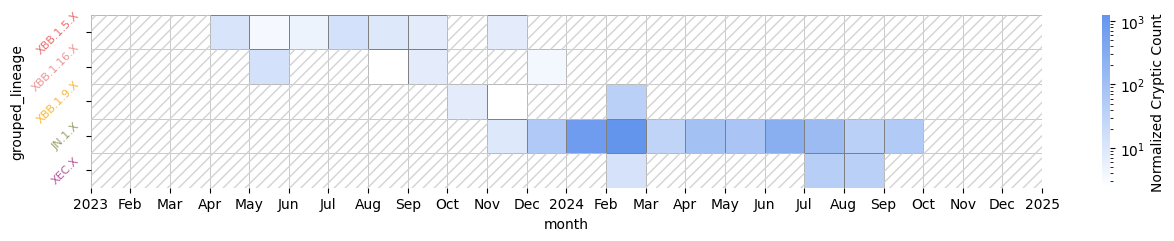

In [12]:
# Plot heatmap of cryptic counts per lineage per month

white_to_blue = mcolors.LinearSegmentedColormap.from_list(
    'white_to_blue', ['white', 'cornflowerblue']
)

fig, ax = plt.subplots(figsize=(13, 2.5))

# Create mask for NaN values
mask = cryptic_pivot.isna()

sns.heatmap(
    cryptic_pivot,
    cmap=white_to_blue, 
    cbar_kws={'label': 'Normalized Cryptic Count'},
    norm=mcolors.LogNorm(),
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

# Add hatching for NaN values
for i in range(len(cryptic_pivot.index)):
    for j in range(len(cryptic_pivot.columns)):
        if mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, 
                                     fill=False, 
                                     edgecolor='lightgray', 
                                     hatch='///', 
                                     linewidth=0.5))
            
tick_positions = [i for i in range(len(cryptic_pivot.columns))]
tick_labels = list(cryptic_pivot.columns)

tick_positions.append(len(cryptic_pivot.columns))
tick_labels.append('2025')

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.tick_params(axis='y', which='major', labelsize=8)
for label in ax.yaxis.get_ticklabels():
    lineage = label.get_text()
    if lineage in colors_dict:
        label.set_color(colors_dict[lineage])

plt.yticks(rotation=45)
 
plt.tight_layout()
plt.savefig('plots/cryptics_heatmap.pdf', transparent=True)